In [1]:
from models.nsf import SplineFlowWindow
import numpy as np
from network_test import _sims_to_tensors, compute_stats
from torch.utils.data import TensorDataset
import torch

In [2]:
data = np.load("dataset.npz")
foot = data["foot"]
com = data["com"]
stats = compute_stats("dataset.npz")
S = foot.shape[0]
split = int(0.7 * S)
train_idx = np.arange(0, split)
test_idx  = np.arange(split, S)
rng = np.random.default_rng(0)
train_idx = rng.permutation(train_idx)
foot_windows_train, coms_train = _sims_to_tensors(foot, com, train_idx, stats)
foot_windows_test, coms_test = _sims_to_tensors(foot, com, test_idx, stats)


────────────────────────────────────────────────────────────
  Step 1/3 – computing normalisation stats
────────────────────────────────────────────────────────────
  Dataset       : dataset.npz
  Window        : 15 frames = 300 ms
  Simulations   : 100,000   frames/sim : 39
  COM std       : [6. 4. 2.] cm


In [3]:
print("X mean:", foot_windows_train.mean().item())
print("X std :", foot_windows_train.std().item())

print("y mean:", coms_train.mean().item())
print("y std :", coms_train.std().item())
#(nsimulations x 36 (n windows per sample))x (window dim x 6foot dimensions)
#(nsimulations x 36) x (3 COM dimensions)
print("Foot windows shape:", foot_windows_train.shape)
print("COM shape:", coms_train.shape)

X mean: -0.005142764188349247
X std : 0.9543936848640442
y mean: -1.0208856676685585e-10
y std : 1.004450798034668
Foot windows shape: torch.Size([1750000, 90])
COM shape: torch.Size([1750000, 3])


In [5]:
print(f"COM: min={coms_train.min():.2f}, max={coms_train.max():.2f}")
print(f"Percentiles: 1%={torch.quantile(coms_train, 0.01):.2f}, 99%={torch.quantile(coms_train, 0.99):.2f}")

COM: min=-9.04, max=5.26
Percentiles: 1%=-2.28, 99%=1.94


In [6]:
print("Per-dimension stats:")
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train[:, i]
    print(f"  {dim}: min={col.min():.2f}, max={col.max():.2f}, "
          f"std={col.std():.2f}, "
          f"1%={torch.quantile(col, 0.01):.2f}, "
          f"99%={torch.quantile(col, 0.99):.2f}")

Per-dimension stats:
  x: min=-2.83, max=2.46, std=1.00, 1%=-1.91, 99%=1.74
  y: min=-9.04, max=3.66, std=0.99, 1%=-2.13, 99%=1.90
  z: min=-3.35, max=5.26, std=1.02, 1%=-2.52, 99%=2.63


In [5]:
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train[:, i]
    for thresh in [3.0, 4.0, 5.0]:
        n = (col.abs() > thresh).sum().item()
        print(f"  {dim}: {n} samples beyond ±{thresh} ({100*n/len(col):.3f}%)")

  x: 0 samples beyond ±3.0 (0.000%)
  x: 0 samples beyond ±4.0 (0.000%)
  x: 0 samples beyond ±5.0 (0.000%)
  y: 572 samples beyond ±3.0 (0.033%)
  y: 4 samples beyond ±4.0 (0.000%)
  y: 4 samples beyond ±5.0 (0.000%)
  z: 16666 samples beyond ±3.0 (0.952%)
  z: 6965 samples beyond ±4.0 (0.398%)
  z: 10 samples beyond ±5.0 (0.001%)


In [5]:
bad_mask = coms_train[:, 1].abs() > 5.0  # 4 samples with large vertical (y) COM values, likely artifacts
print(f"Dropping {bad_mask.sum()} bad frames")
coms_train_filtered = coms_train[~bad_mask]
windows_train_filtered = foot_windows_train[~bad_mask]
print(coms_train_filtered.shape, windows_train_filtered.shape)

Dropping 6 bad frames
torch.Size([1749994, 3]) torch.Size([1749994, 90])


In [6]:
# Run this before training, on your filtered data
print(f"COM filtered: min={coms_train_filtered.min():.4f}, max={coms_train_filtered.max():.4f}")
print("Per-dim:")
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train_filtered[:, i]
    print(f"  {dim}: min={col.min():.4f}, max={col.max():.4f}")

COM filtered: min=-3.8079, max=5.2596
Per-dim:
  x: min=-2.8316, max=2.4624
  y: min=-3.8079, max=3.6613
  z: min=-3.3525, max=5.2596


In [3]:
#I also need to apply filter from training data to test data
#he test set should never be filtered based on its own statistics, apply the exact same thresholds derived from the training set
bad_mask = coms_test[:, 1].abs() > 5.0  
print(f"Dropping {bad_mask.sum()} bad frames")
coms_test_filtered = coms_test[~bad_mask]
windows_test_filtered = foot_windows_test[~bad_mask]
print(coms_test_filtered.shape, windows_test_filtered.shape)

Dropping 0 bad frames
torch.Size([750000, 3]) torch.Size([750000, 90])


In [6]:
TAILBOUND = float(coms_train_filtered.abs().max()) * 1.1

In [7]:
train_dataset = TensorDataset(windows_train_filtered, coms_train_filtered)
test_dataset = TensorDataset(windows_test_filtered, coms_test_filtered)

In [9]:
print(f"TAILBOUND: {TAILBOUND}")
print(f"train dataset COM: min={train_dataset.tensors[1].min():.4f}, max={train_dataset.tensors[1].max():.4f}")
print(f"test dataset COM: min={test_dataset.tensors[1].min():.4f}, max={test_dataset.tensors[1].max():.4f}")

TAILBOUND: 5.785606336593628
train dataset COM: min=-3.8079, max=5.2596
test dataset COM: min=-3.7623, max=5.1644


In [7]:
train_max = float(coms_train_filtered.abs().max())
print(f"train max abs: {train_max:.4f}")
print(f"TAILBOUND: {TAILBOUND:.4f}")
print(f"test max abs: {float(coms_test_filtered.abs().max()):.4f}")

train max abs: 5.2596
TAILBOUND: 5.7856
test max abs: 5.1644


In [8]:
model = SplineFlowWindow(
    window_dim=90,
    blocks=6,
    num_bins=10,
    tail_bound=TAILBOUND
).to("cuda")

In [ ]:
from models.nsf import train_inn_cond3D

In [10]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim, mode="min", factor=0.5, patience=10
)

history = train_inn_cond3D(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    optim=optim,
    epochs=200,
    batch_size=256,
    shuffle=True,
    lr_scheduler=scheduler,
)

torch.save({
    'model_state_dict': model.state_dict(),
    'window_dim': 90,
    'blocks': 6,
    'num_bins': 10,
    'history': history,
}, "nsf_window.pt")

Training: 100%|██████████| 200/200 [8:41:28<00:00, 156.44s/it, test_loss=-7.22, train_loss=-7.31]  


In [9]:
checkpoint = torch.load("nsf_window1.pt", map_location="cpu")
finalmodel = SplineFlowWindow(
    window_dim=90,
    blocks=6,
    num_bins=10,
    tail_bound=TAILBOUND
).to("cpu")
finalmodel.load_state_dict(checkpoint['model_state_dict'])
finalmodel.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (coupling_blocks): ModuleList(
      (0-5): 6 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=31, bias=True)
        )
      )
    )
  )
)

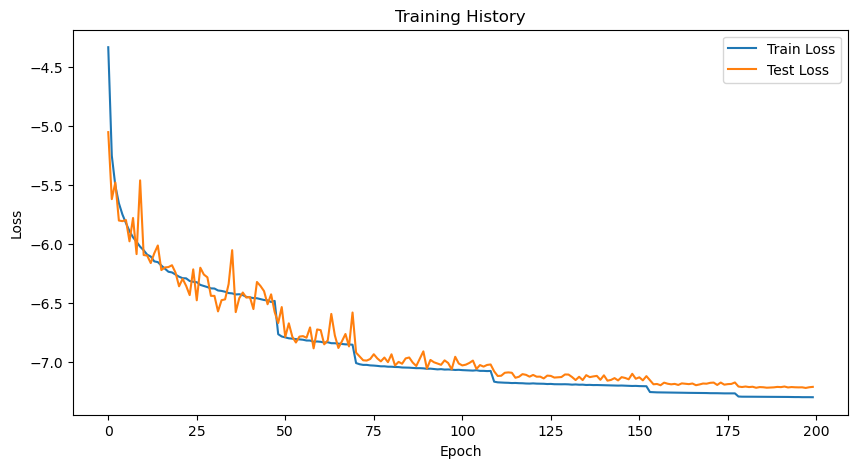

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(checkpoint["history"]['train_loss'], label='Train Loss')
plt.plot(checkpoint["history"]['test_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

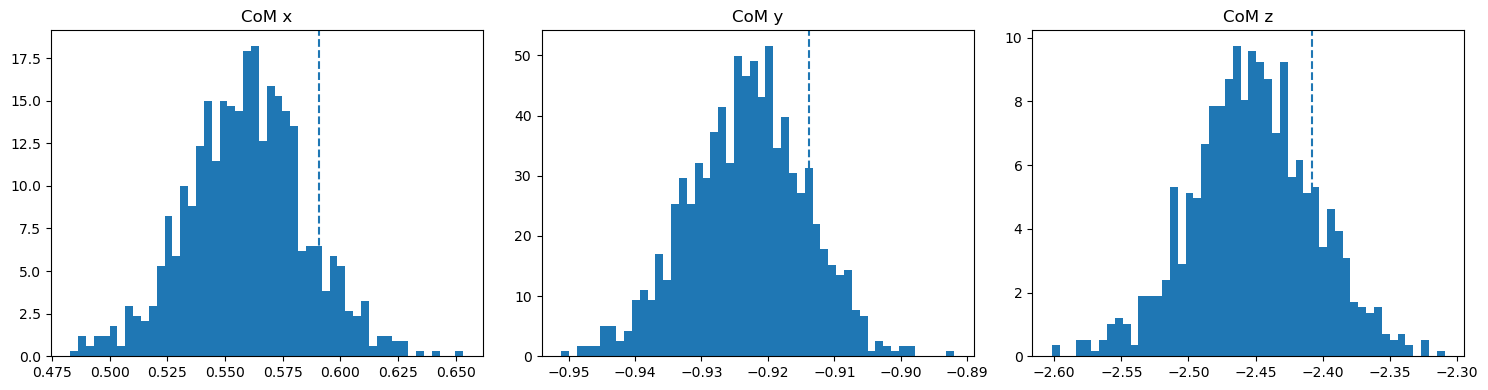

In [11]:
window, com = test_dataset[200]
window = window.unsqueeze(0).to("cpu")        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to("cpu") 
com = com.cpu().numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = finalmodel.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].cpu().numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

#### MODEL HYPERPARMATER SELECTION

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model_1 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=256, num_bins=10).to(device)
optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_1,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_1.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 256,
    "num_bins": 10,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{1}.pt")

Training:   2%|▏         | 1/50 [07:16<5:56:48, 436.91s/it, test_loss=-7.72, train_loss=-7.17]


KeyboardInterrupt: 

In [ ]:
model_2 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=512, num_bins=10).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_2,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_2.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 512,
    "num_bins": 10,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{2}.pt")

In [ ]:
model_3 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=256, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_3,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_3.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 256,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{3}.pt")

In [ ]:
model_4 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=5, tail_bound=TAILBOUND, hidden_size=512, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_4,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_4.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 5,
    "hidden_size": 512,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{4}.pt")

In [ ]:
model_5 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=6, tail_bound=TAILBOUND, hidden_size=512, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_5,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_5.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 6,
    "hidden_size": 512,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{5}.pt")

In [11]:
model_1 = torch.load(f"slidingwindow_1conhistory.pt", map_location=device)

#### Model evaluation

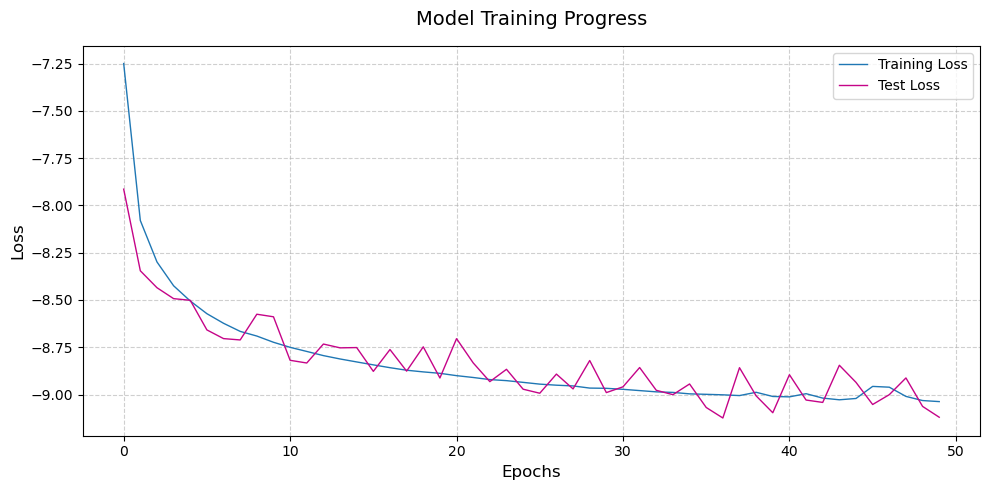

In [13]:
import matplotlib.pyplot as plt
history = model_1["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [14]:
model = SplineFlowWindow(model_1["config"]["window_dim"], blocks=model_1["config"]["blocks"], tail_bound=5.7856, hidden_size=model_1["config"]["hidden_size"], num_bins=model_1["config"]["num_bins"]).to(device)
model.load_state_dict(model_1["model_state"])
model.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-3): 4 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=31, bias=True)
        )
      )
    )
  )
)

In [ ]:
x, y = train_dataset[0]
x = x.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
theta = y.unsqueeze(0).to(device) # shape [1, theta_dim]

with torch.no_grad():
    output = model(x, theta)
with torch.no_grad():
    out = model(x, theta) 
print(out.shape)

torch.Size([1, 3])


#### Internal validation

##### Sample from posterior

Visualize posterior for one window

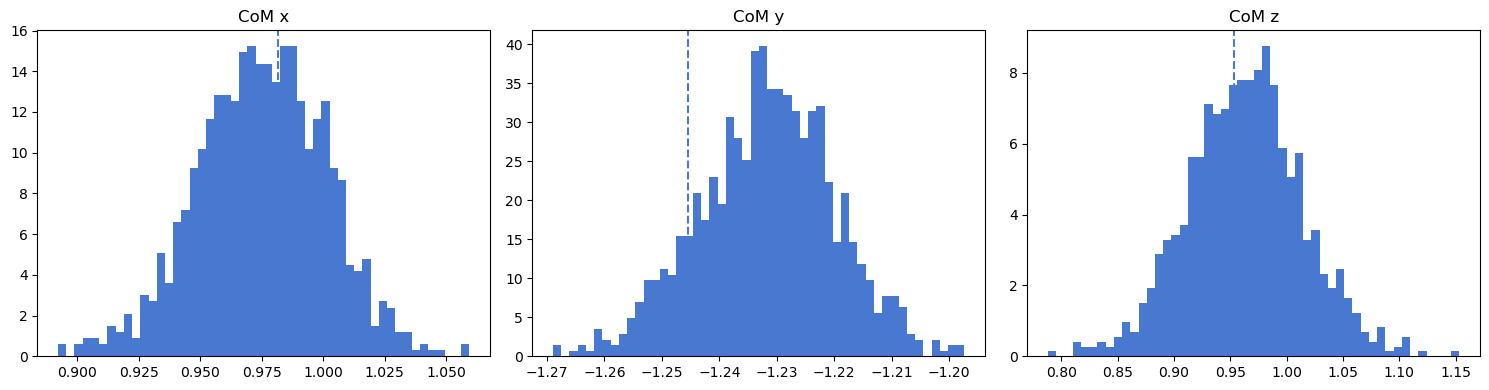

In [15]:
window, com = test_dataset[100]
window = window.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to(device) 
com = com.numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = model.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
model_2 = torch.load(f"slidingwindow_2.pt", map_location=device)

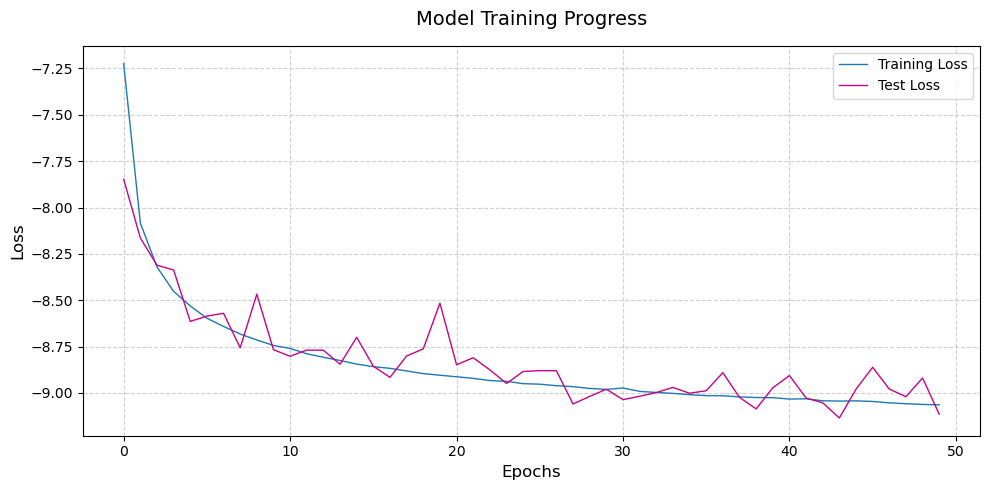

In [20]:
import matplotlib.pyplot as plt
history = model_2["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [16]:
model2 = SplineFlowWindow(model_2["config"]["window_dim"], blocks=model_2["config"]["blocks"], tail_bound=5.7856, hidden_size=model_2["config"]["hidden_size"], num_bins=model_2["config"]["num_bins"]).to(device)
model2.load_state_dict(model_2["model_state"])
model2.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-3): 4 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
          (3): ReLU()
          (4): Linear(in_features=512, out_features=31, bias=True)
        )
      )
    )
  )
)

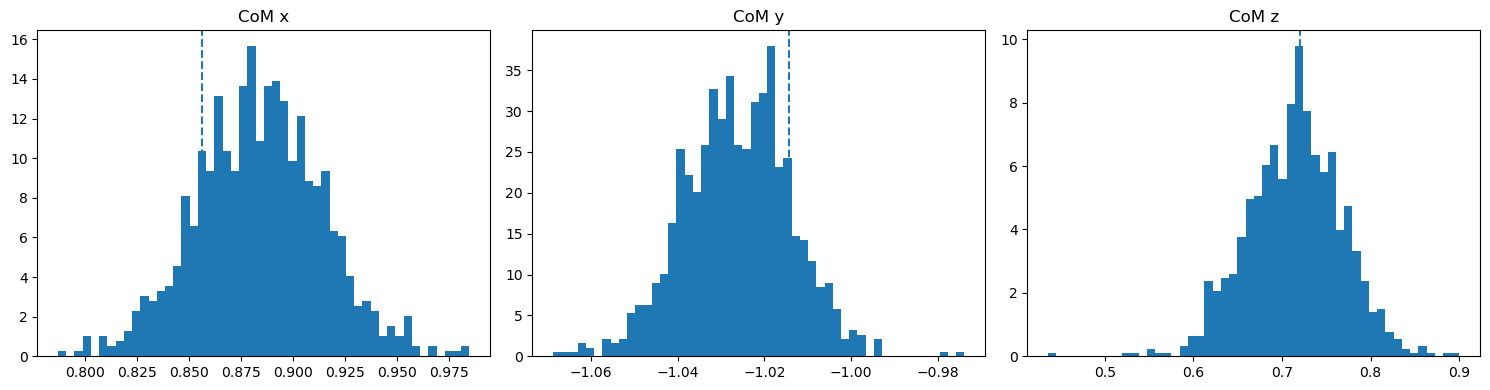

In [17]:
window, com = test_dataset[50]
window = window.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to(device) 
com = com.numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = model2.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

In [22]:
model_3 = torch.load(f"slidingwindow_3.pt", map_location=device)
model3 = SplineFlowWindow(model_3["config"]["window_dim"], blocks=model_3["config"]["blocks"], tail_bound=5.7856, hidden_size=model_3["config"]["hidden_size"], num_bins=model_3["config"]["num_bins"]).to(device)
model3.load_state_dict(model_3["model_state"])
model3.eval()
print(model_3["config"])

{'window_dim': 90, 'blocks': 4, 'hidden_size': 256, 'num_bins': 12, 'epochs': 50, 'batch_size': 128, 'lr': 0.001, 'history': {'train_loss': [-7.234102828367194, -8.071454045309878, -8.296144651079828, -8.424555415234417, -8.514510055195172, -8.583998591920924, -8.638683477620079, -8.666416153342077, -8.708265473598322, -8.736719753864076, -8.760441073770272, -8.788122290152671, -8.807386793187636, -8.828238403123935, -8.845794919604174, -8.860222379748844, -8.871895184119882, -8.881798052192195, -8.89539227575433, -8.905832572233571, -8.916873757005565, -8.921618901843397, -8.93270890091197, -8.936988951660434, -8.950127136575999, -8.953584467531012, -8.958539501483408, -8.966336614164911, -8.975377318257461, -8.97620177015195, -8.988065383626987, -8.993672445428201, -8.992008037026148, -9.003271339292795, -9.006457254132782, -9.008940744092778, -9.018439397692239, -9.019513020178406, -9.0223749262604, -9.02823580462513, -9.030459891240826, -9.038016023513118, -9.041073191866985, -9.04

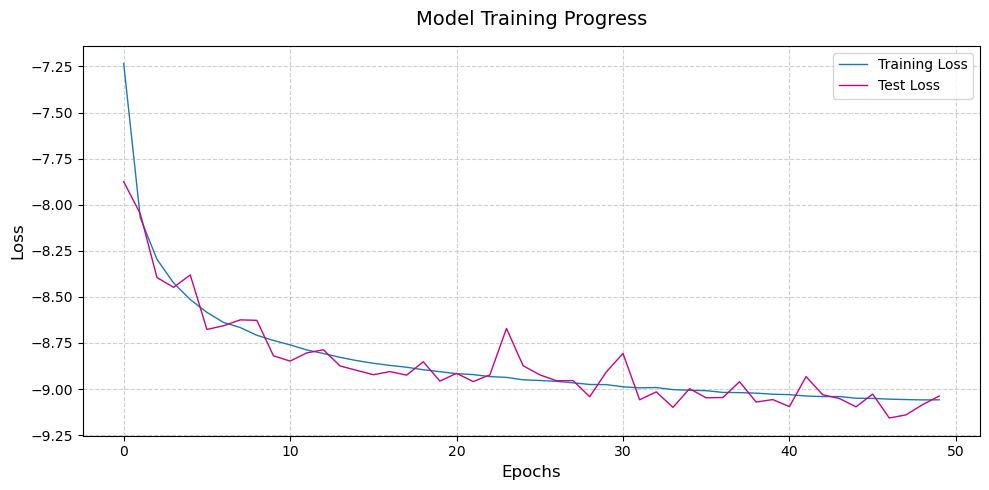

In [26]:
import matplotlib.pyplot as plt
history = model_3["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [24]:
model_4 = torch.load(f"slidingwindow_4.pt", map_location=device)
model4 = SplineFlowWindow(model_4["config"]["window_dim"], blocks=model_4["config"]["blocks"], tail_bound=5.7856, hidden_size=model_4["config"]["hidden_size"], num_bins=model_4["config"]["num_bins"]).to(device)
model4.load_state_dict(model_4["model_state"])
model4.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-4): 5 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
          (3): ReLU()
          (4): Linear(in_features=512, out_features=37, bias=True)
        )
      )
    )
  )
)

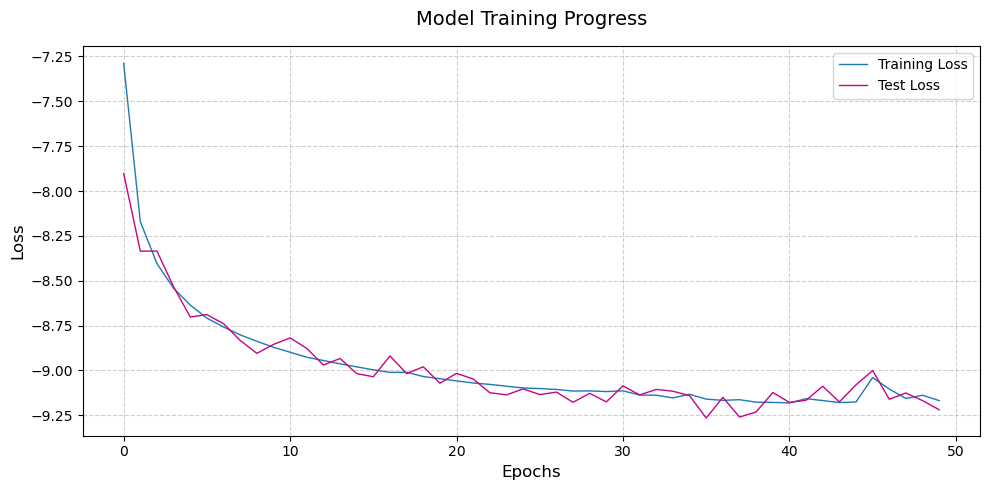

In [27]:
import matplotlib.pyplot as plt
history = model_4["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# window_dim=90, hidden_size=256, blocks=4, num_bins=10, tail_bound=6.0

In [29]:
model_1 = torch.load(f"windowencoder_1.pt", map_location=device)
model1 = SplineFlowWindow(model_1["config"]["window_dim"], blocks=model_1["config"]["blocks"], tail_bound=TAILBOUND, hidden_size=model_1["config"]["hidden_size"], num_bins=model_1["config"]["num_bins"]).to(device)
model1.load_state_dict(model_1["model_state"])
model1.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'windowencoder_1.pt'

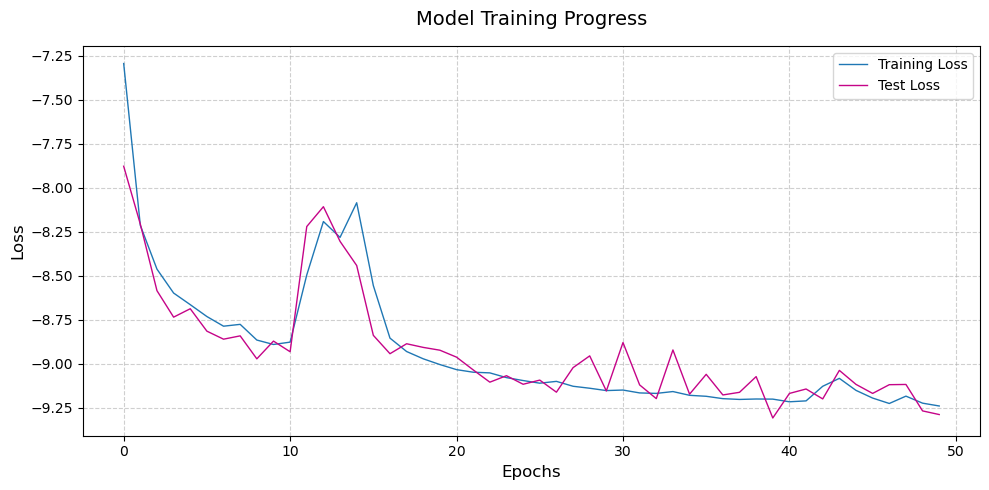

In [28]:
import matplotlib.pyplot as plt
history = model_5["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### INTERNAL VALIDATION

each slide window

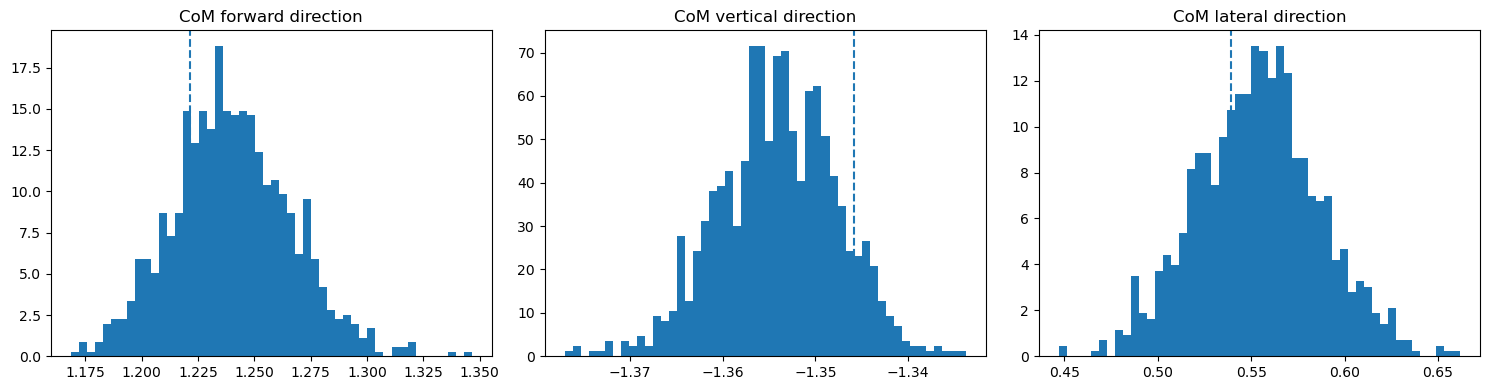

In [27]:
from internal_validation import plot_posterior_samples
plot_posterior_samples(finalmodel, test_dataset, n_samples=1000, idx=50)

Energy error: 0.0306
Mean l2 error: 0.0432


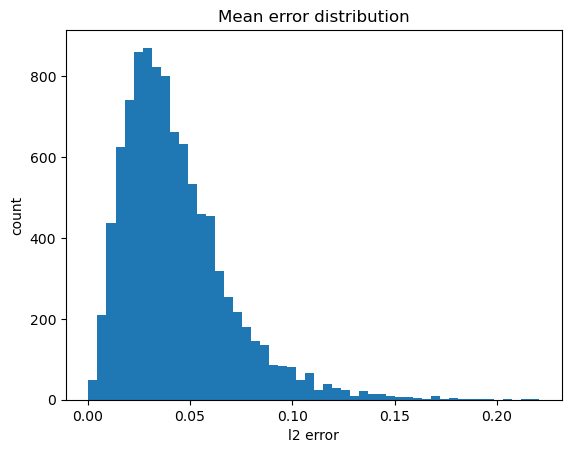

Mean error: 0.0432


In [14]:
from internal_validation import evaluate_energy, evaluate_mean_error
from torch.utils.data import Subset
test_dataset_10k = Subset(test_dataset, range(10000))
energy_error = evaluate_energy(finalmodel, test_dataset_10k, n_samples=500)
print(f"Energy error: {energy_error:.4f}")
mean_error, error_perwindow = evaluate_mean_error(finalmodel, test_dataset_10k, n_samples=500)
print(f"Mean error: {mean_error:.4f}")

In [16]:
import numpy as np
import math
import torch
import matplotlib.pyplot as plt
from scipy import stats

def calibration_check_3d(
    model,
    test_dataset,          # TensorDataset(windows, coms) — as in your notebook
    M=200,                 # posterior samples per test point
    B=10,                  # histogram bins
    N_test=None,           # how many test points to use (None = all)
    device="cuda",
):
    """
    Calibration check for SplineFlowWindow.
    Target is 3D COM (already standardized), no PCA inverse transform needed.
    For each test point i and each dimension j in {x, y, z}:
      - Draw M samples from posterior p(com | window_i)
      - Form dataset of size M+1: M samples + ground truth com_i*
      - Sort and find rank [m]* of com_i* among the M+1 values
      - Compute r_ij = [m]* / (M+2)
    If model is perfect, {r_ij}_i are uniform in [0,1] for each j.
    """
    model.eval()
    model.to(device)

    N = len(test_dataset) if N_test is None else min(N_test, len(test_dataset))
    dim_names = ['x', 'y', 'z']
    n_dims = 3

    all_ranks = np.zeros((N, n_dims))  # r_ij

    with torch.no_grad():
        for i in range(N):
            window, com_true = test_dataset[i]
            window = window.unsqueeze(0).to(device)     # (1, window_dim)
            com_true_np = com_true.cpu().numpy()         # (3,)

            # (a) sample M times from posterior
            com_samples = model.sample(window, M).cpu().numpy()  # (M, 3)

            # (b) form dataset of size M+1: samples ∪ {com_true}
            combined = np.concatenate(
                [com_samples, com_true_np[None, :]], axis=0
            )  # (M+1, 3)

            # (c) for each dimension j, find rank [m]* of ground truth
            for j in range(n_dims):
                sorted_indices = np.argsort(combined[:, j])
                rank = np.where(sorted_indices == M)[0][0]  # M is the GT index
                all_ranks[i, j] = rank / (M + 2)

    # ── TEST 1: Histogram test ──────────────────────────────────────────
    expected = N / B
    std_binom = np.sqrt(N * (1/B) * (1 - 1/B))

    fig1, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j in range(n_dims):
        counts, edges = np.histogram(all_ranks[:, j], bins=B, range=(0, 1))
        bin_centers = (edges[:-1] + edges[1:]) / 2
        axes[j].bar(bin_centers, counts, width=1/B, alpha=0.7, color='steelblue')
        axes[j].axhline(expected,              color='k', linestyle='--', label='Expected')
        axes[j].axhline(expected + 2*std_binom, color='r', linestyle=':', label='±2σ')
        axes[j].axhline(expected - 2*std_binom, color='r', linestyle=':')
        axes[j].set_title(f'COM {dim_names[j]}')
        axes[j].set_xlabel('r_ij')
        axes[j].set_ylabel('Count')
        axes[j].legend(fontsize=8)
    plt.suptitle('Test 1: Histogram calibration check (should be flat)')
    plt.tight_layout()
    plt.show()

    # ── TEST 2: ECDF test ───────────────────────────────────────────────
    t = np.linspace(0, 1, 300)
    band = np.sqrt(t * (1 - t))

    fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j in range(n_dims):
        r_j = np.sort(all_ranks[:, j])
        ecdf = np.array([np.mean(r_j <= ti) for ti in t])
        curve = np.sqrt(N) * (ecdf - t)

        axes[j].plot(t, curve, label='√N·(ECDF-t)', linewidth=1.5)
        axes[j].fill_between(t, -band, band, alpha=0.2, color='gray', label='±√(t(1-t))')
        axes[j].axhline(0, color='k', linewidth=0.8)
        axes[j].set_title(f'COM {dim_names[j]}')
        axes[j].set_xlabel('t')
        axes[j].legend(fontsize=8)

        # background color: overconfident = red, underconfident = blue
        if np.any(curve > band):
            axes[j].set_facecolor('#fff0f0')
        elif np.any(curve < -band):
            axes[j].set_facecolor('#f0f0ff')

    plt.suptitle('Test 2: ECDF calibration check (should stay within gray band)')
    plt.tight_layout()
    plt.show()

    # ── KS test summary ─────────────────────────────────────────────────
    print("\nKolmogorov-Smirnov uniformity test per dimension:")
    print(f"{'Dim':<6} {'KS stat':<12} {'p-value':<12} {'Calibrated?'}")
    print("-" * 45)
    for j in range(n_dims):
        ks_stat, p_val = stats.kstest(all_ranks[:, j], 'uniform')
        calibrated = "✅" if p_val > 0.05 else "❌"
        print(f"{dim_names[j]:<6} {ks_stat:<12.4f} {p_val:<12.4f} {calibrated}")

    return all_ranks

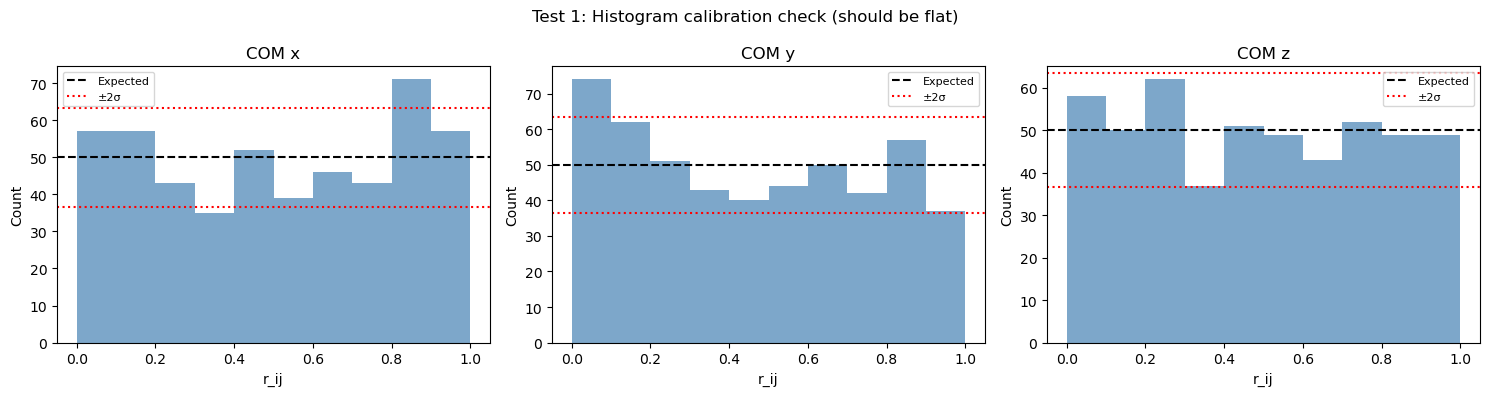

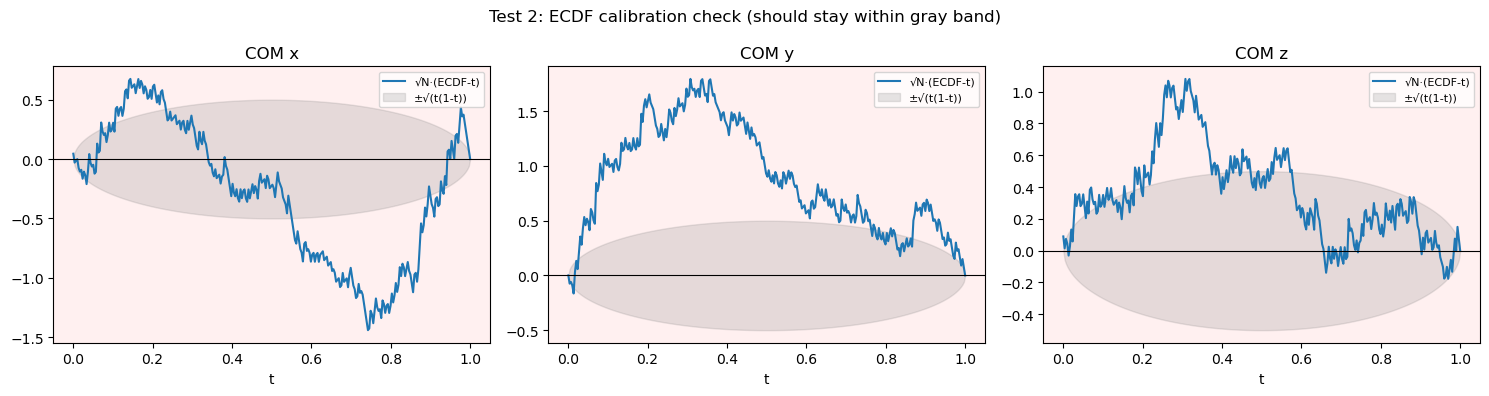


Kolmogorov-Smirnov uniformity test per dimension:
Dim    KS stat      p-value      Calibrated?
---------------------------------------------
x      0.0655       0.0261       ❌
y      0.0825       0.0021       ❌
z      0.0501       0.1568       ✅


In [18]:
all_ranks = calibration_check_3d(
    model=finalmodel,
    test_dataset=test_dataset,   # TensorDataset(windows_test_filtered, coms_test_filtered)
    M=200,
    B=10,
    N_test=500,   # 500 test points is plenty for 3 dims
    device="cpu",
)

In [12]:
from network_test import extract_kinematics, make_windows, SAMPLE_RATE, WINDOW_FRAMES
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def compare_real_trajectory(
    model,
    stats,                          # from compute_stats("dataset.npz")
    model_path="gait2392_simbody.osim",
    mot_path="walk.mot",
    M=200,                          # posterior samples per frame
    device="cuda",
    plot_output="nsf_real_comparison.png",
):
    """
    Compares SplineFlowWindow posterior predictions against a real .mot trajectory.
    For each window frame:
      - draws M samples from p(com | window)
      - plots posterior mean ± std against ground truth COM
      - computes RMSE and MMD per axis
    """
    # ── Step 1: extract kinematics from .mot via OpenSim ───────────────
    print("Extracting kinematics from .mot file...")
    times, foot_data, com_true = extract_kinematics(model_path, mot_path)
    # times:     (T,)    resampled to SAMPLE_RATE Hz
    # foot_data: (T, 6)  raw foot positions
    # com_true:  (T, 3)  raw COM positions

    # ── Step 2: build windows using the same pipeline as training ───────
    W = WINDOW_FRAMES
    foot_mean = np.array(stats["foot_mean"], dtype=np.float32)
    foot_std  = np.array(stats["foot_std"],  dtype=np.float32)
    com_mean  = np.array(stats["com_mean"],  dtype=np.float32)
    com_std   = np.array(stats["com_std"],   dtype=np.float32)

    X_rel, com_rel_true = make_windows(foot_data, com_true, W)
    # X_rel:        (N_windows, W*6)  relative foot windows, unnormalized
    # com_rel_true: (N_windows, 3)    COM relative to foot midpoint, mean removed

    X_norm = (X_rel - foot_mean) / foot_std          # normalize exactly as training
    times_win = times[:len(times) - W + 1]           # one timestamp per window

    N_windows = X_norm.shape[0]
    print(f"Windows: {N_windows}  ({times_win[0]:.3f}s – {times_win[-1]:.3f}s)")

    # ── Step 3: run posterior sampling frame by frame ───────────────────
    model.eval()
    model.to(device)

    all_means = np.zeros((N_windows, 3))
    all_stds  = np.zeros((N_windows, 3))
    all_samples = []  # list of (M, 3) arrays — kept for calibration/energy score

    print(f"Sampling {M} posteriors per frame...")
    with torch.no_grad():
        for i in range(N_windows):
            window = torch.from_numpy(X_norm[i:i+1]).to(device)  # (1, W*6)
            samples_norm = model.sample(window, M).cpu().numpy()  # (M, 3)

            # denormalize back to COM-relative-to-foot space (metres)
            samples = samples_norm * com_std + com_mean           # (M, 3)
            all_means[i] = samples.mean(axis=0)
            all_stds[i]  = samples.std(axis=0)
            all_samples.append(samples)

    all_samples = np.stack(all_samples)   # (N_windows, M, 3)

    # denormalize ground truth as well
    com_gt = com_rel_true * com_std + com_mean   # (N_windows, 3)

    # ── Step 4: metrics ─────────────────────────────────────────────────
    from network_test import rmse_cm, mmd_exponential

    axis_labels = ["X – forward (AP)", "Y – vertical", "Z – lateral (ML)"]
    axis_short  = ["X", "Y", "Z"]
    c_gt        = ["#2166ac", "#1a9850", "#d6604d"]
    c_pred      = ["#74add1", "#a6d96a", "#f4a582"]
    c_band      = ["#cce5ff", "#ccf0d5", "#fdd5c8"]

    rmse_list, mae_list = [], []
    for i in range(3):
        rmse_list.append(float(np.sqrt(np.mean((all_means[:, i] - com_gt[:, i])**2)) * 100))
        mae_list.append(float(np.mean(np.abs(all_means[:, i] - com_gt[:, i])) * 100))

    overall_rmse = float(np.sqrt(np.mean((all_means - com_gt)**2)) * 100)
    overall_mmd  = mmd_exponential(all_means, com_gt)

    # ── Step 5: plot ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(
        f"SplineFlowWindow – real trajectory validation ({mot_path})\n"
        f"Posterior mean ± 1σ vs ground truth  |  "
        f"RMSE={overall_rmse:.2f}cm  MMD={overall_mmd:.4f}  "
        f"M={M} samples/frame",
        fontsize=11, fontweight="bold"
    )
    gs = gridspec.GridSpec(3, 2, width_ratios=[3, 1], hspace=0.5, wspace=0.35)

    for i in range(3):
        gt   = com_gt[:, i] * 100       # metres → cm
        mean = all_means[:, i] * 100
        std  = all_stds[:, i] * 100
        err  = mean - gt

        ax_ts = fig.add_subplot(gs[i, 0])
        ax_ts.plot(times_win, gt,   color=c_gt[i],   lw=1.8, label="ground truth")
        ax_ts.plot(times_win, mean, color=c_pred[i], lw=1.8, ls="--", label="posterior mean")
        ax_ts.fill_between(times_win, mean - std, mean + std,
                           alpha=0.35, color=c_band[i], label="±1σ posterior")
        ax_ts.set_xlabel("time [s]", fontsize=9)
        ax_ts.set_ylabel(f"COM {axis_short[i]} [cm]", fontsize=9)
        ax_ts.set_title(
            f"{axis_labels[i]}   RMSE={rmse_list[i]:.2f}cm  MAE={mae_list[i]:.2f}cm",
            fontsize=9
        )
        ax_ts.legend(fontsize=8, loc="upper right")
        ax_ts.grid(alpha=0.3)

        ax_er = fig.add_subplot(gs[i, 1])
        ax_er.plot(times_win, err, color="#555555", lw=1.0)
        ax_er.fill_between(times_win, -std, std,
                           alpha=0.2, color=c_band[i], label="±1σ")
        ax_er.axhline(0, color="black", lw=0.8, ls="--")
        ax_er.set_xlabel("time [s]", fontsize=9)
        ax_er.set_ylabel("error [cm]", fontsize=9)
        ax_er.set_title(f"error  (max={np.abs(err).max():.2f}cm)", fontsize=9)
        ax_er.grid(alpha=0.3)

    plt.savefig(plot_output, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved → {plot_output}")

    # ── Step 6: summary table ───────────────────────────────────────────
    print(f"\n  {'axis':<6}  {'RMSE [cm]':>10}  {'MAE [cm]':>9}  {'avg σ [cm]':>11}")
    print(f"  {'─'*45}")
    for i, a in enumerate(axis_short):
        print(f"  {a:<6}  {rmse_list[i]:>10.3f}  {mae_list[i]:>9.3f}  "
              f"{all_stds[:, i].mean()*100:>11.3f}")
    print(f"  {'─'*45}")
    print(f"  {'total':<6}  {overall_rmse:>10.3f}  MMD={overall_mmd:.5f}")

    return all_samples, com_gt, times_win

Extracting kinematics from .mot file...

  Model  : gait2392_simbody.osim
  Motion : normal.mot
  Frames : 51  (0.000s – 1.000s)
  Running forward kinematics... done.
Windows: 36  (0.000s – 0.714s)
Sampling 200 posteriors per frame...


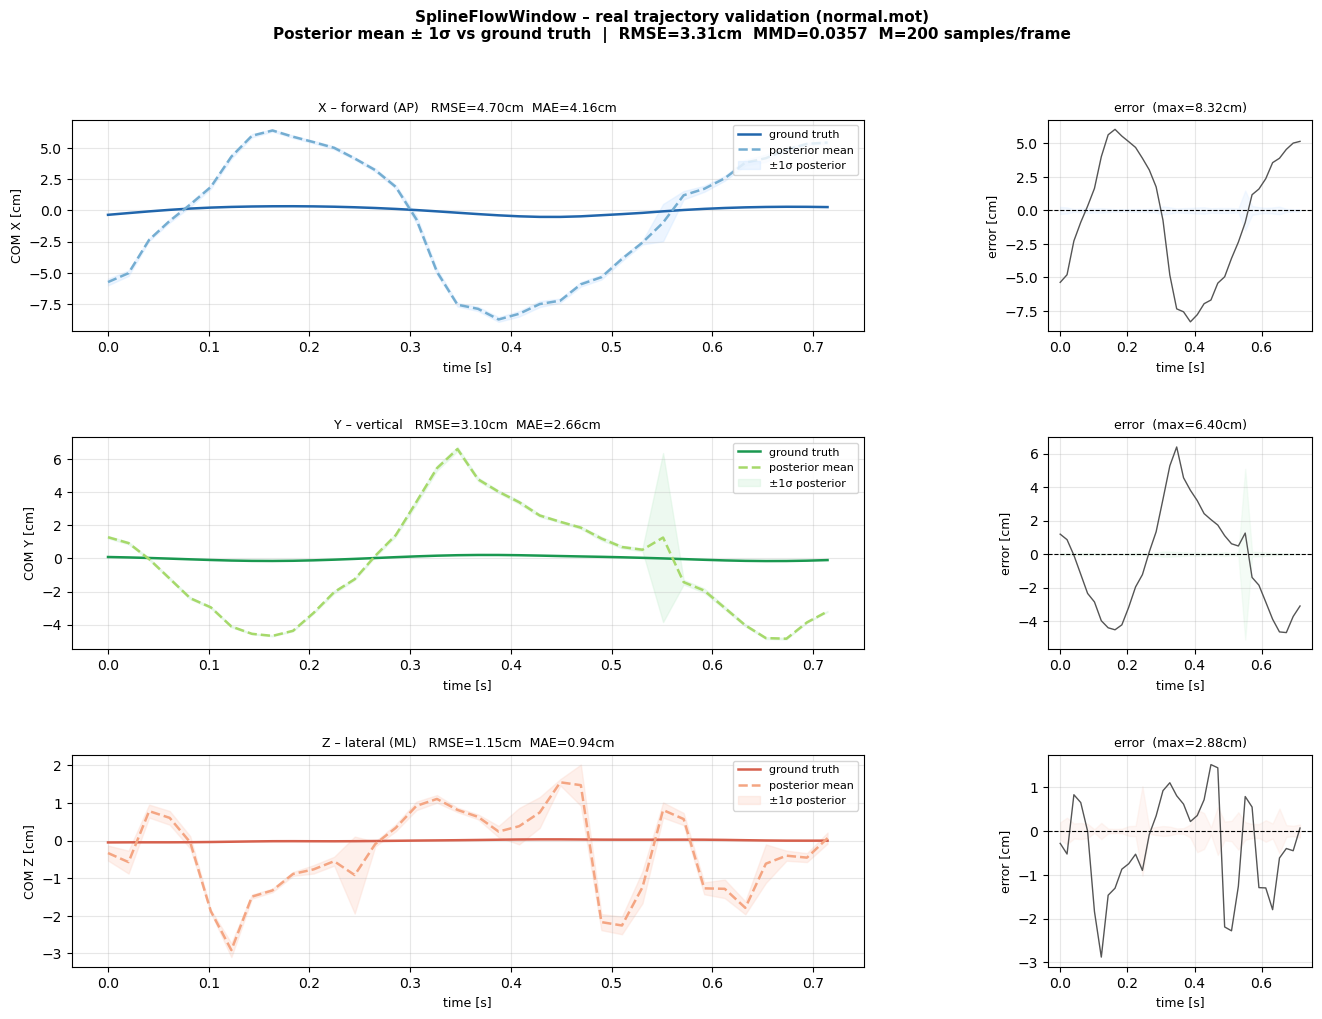


Plot saved → nsf_real_comparison.png

  axis     RMSE [cm]   MAE [cm]   avg σ [cm]
  ─────────────────────────────────────────────
  X            4.695      4.164        0.211
  Y            3.098      2.663        0.217
  Z            1.150      0.943        0.210
  ─────────────────────────────────────────────
  total        3.315  MMD=0.03572


In [15]:
all_samples, com_gt, times_win = compare_real_trajectory(
    model=finalmodel,
    stats=stats,                        # already computed at the top of your notebook
    model_path="gait2392_simbody.osim",
    mot_path="normal.mot",
    M=200,
    device="cpu",
)

trajectory of windows

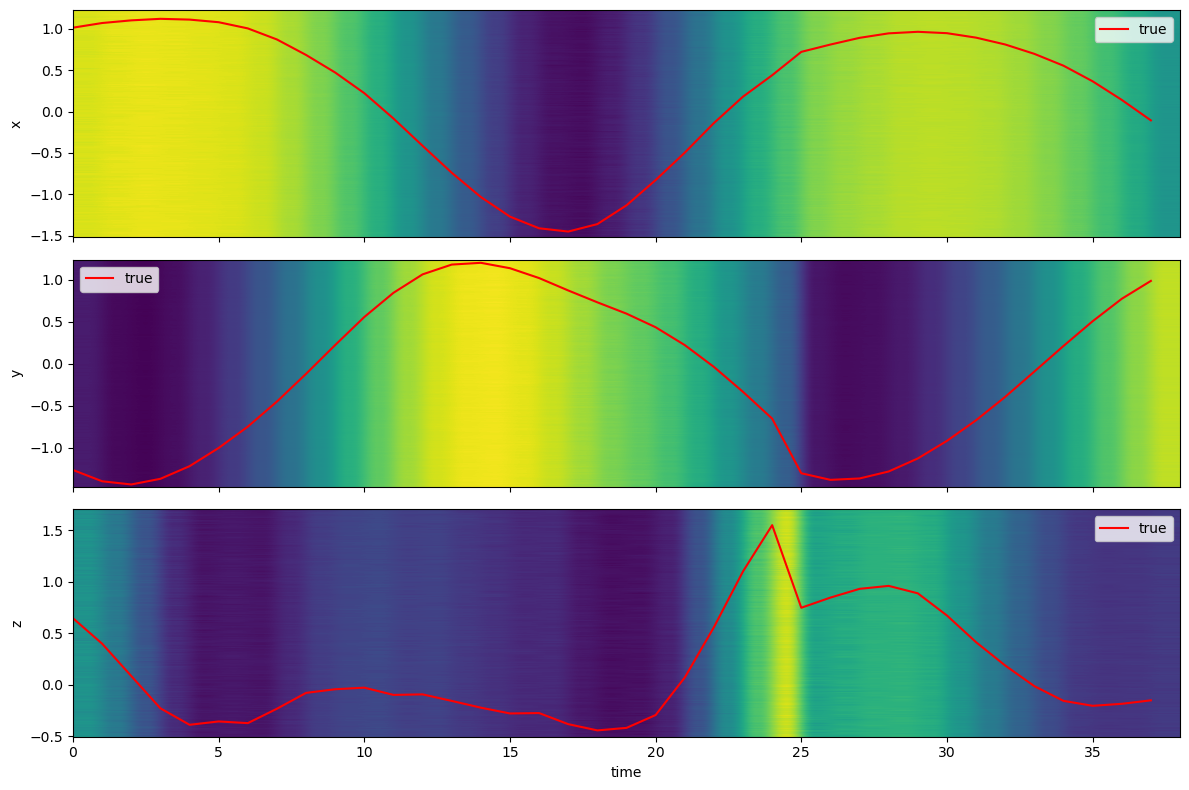

In [ ]:
from internal_validation import get_posterior_samples_over_time, plot_trajectory_density
samples_over_time = get_posterior_samples_over_time(finalmodel, foot_windows[:38], n_samples=1000)
plot_trajectory_density(coms[:38], samples_over_time)

In [ ]:
#only want to keep full trajectories in test set
num_full = foot_windows_test.shape[0] // 39
total_keep = num_full * 39
X_trimmed = foot_windows_test[-total_keep:]
Y_trimmed = coms_test_filtered[-total_keep:]
X_seq = X_trimmed.view(num_full, 39, -1)
Y_seq = Y_trimmed.view(num_full, 39, -1)

In [26]:
from internal_validation import trajectory_energy_score, get_posterior_samples_over_time, sample_trajectory_paths
total_energy = 0.0

for foottraj, comtraj in zip(X_seq, Y_seq):
    samples = get_posterior_samples_over_time(finalmodel, foottraj, n_samples=300)
    trajs = sample_trajectory_paths(samples, n_traj=20)  # shape (39, 3)
    energy = trajectory_energy_score(trajs, comtraj.cpu().numpy())
    total_energy += energy
print(f"Average trajectory energy score: {total_energy / len(X_seq):.4f}")

Average trajectory energy score: 0.2368


In [28]:
def evaluate_mean_error_trajectories(
    model,
    windows_list,     # list of [N_windows, window_dim]
    true_trajs,       # list of [N_windows, 3]
    n_samples=200,
    n_traj_samples=50,
    device="cpu"
):
    """
    Returns:
        mean_error: scalar (average over trajectories)
        all_errors: list of per-trajectory errors
    """

    model.eval()
    errors = []

    with torch.no_grad():
        for windows, true_traj in zip(windows_list, true_trajs):

            windows = windows.to(device)
            true_traj = true_traj.to(device)

            # 1. posterior samples per window
            all_samples = get_posterior_samples_over_time(
                model, windows, n_samples=n_samples, device=device
            )  # [T, n_samples, 3]

            # 2. sample full trajectories
            traj_samples = sample_trajectory_paths(
                all_samples, n_traj=n_traj_samples
            )  # [n_traj, T, 3]

            # 3. mean trajectory
            mean_traj = traj_samples.mean(dim=0)  # [T, 3]

            # 4. trajectory L2 error
            error = torch.norm(mean_traj - true_traj)  # global L2 over trajectory
            errors.append(error.item())

    mean_error = np.mean(errors)

    print(f"Mean trajectory L2 error: {mean_error:.4f}")

    # histogram
    plt.hist(errors, bins=50)
    plt.title("Trajectory mean error distribution")
    plt.xlabel("L2 error")
    plt.ylabel("count")
    plt.show()

    return mean_error, errors

In [ ]:
evaluate_mean_error_trajectories(finalmodel, X_seq, Y_seq)